# 作业C：图像噪声与PSNR

本作业使用 NumPy 给图像添加不同强度的高斯噪声和泊松噪声，
手动实现 PSNR 评价函数，并比较不同噪声水平下的图像质量。

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(
    precision=4,
    suppress=True
)

height = 256
width = 256

# 创建横向渐变背景
background = np.linspace(
    0.05,
    0.35,
    width,
    dtype=np.float32
)

clean_image = np.zeros(
    (height, width),
    dtype=np.float32
)

# 利用广播将一行背景扩展到整幅图像
clean_image[:, :] = background

# 添加两个亮度不同的矩形结构
clean_image[48:208, 48:208] = 0.55
clean_image[88:168, 88:168] = 0.90

print("图像形状：", clean_image.shape)
print("数据类型：", clean_image.dtype)
print("最小值：", clean_image.min())
print("最大值：", clean_image.max())

图像形状： (256, 256)
数据类型： float32
最小值： 0.05
最大值： 0.9


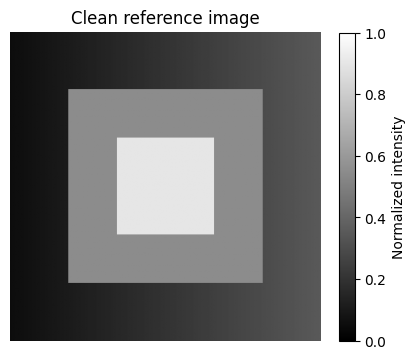

In [2]:
plt.figure(
    figsize=(5, 5)
)

image_plot = plt.imshow(
    clean_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

plt.title("Clean reference image")
plt.axis("off")

plt.colorbar(
    image_plot,
    label="Normalized intensity",
    shrink=0.8
)

plt.show()

In [3]:
def calculate_psnr(
    reference_image,
    test_image,
    data_range=1.0
):
    """手动计算两幅图像之间的PSNR。"""

    reference_image = np.asarray(
        reference_image,
        dtype=np.float64
    )

    test_image = np.asarray(
        test_image,
        dtype=np.float64
    )

    if reference_image.shape != test_image.shape:
        raise ValueError(
            "两幅图像的形状必须一致"
        )

    difference = (
        reference_image - test_image
    )

    mse = np.mean(
        difference ** 2
    )

    # 两幅图完全相同时，MSE为0
    if mse == 0:
        return np.inf

    psnr = 10.0 * np.log10(
        data_range ** 2 / mse
    )

    return psnr

In [4]:
same_image_psnr = calculate_psnr(
    clean_image,
    clean_image
)

print(
    "完全相同图像的PSNR：",
    same_image_psnr
)

完全相同图像的PSNR： inf


In [5]:
slightly_changed_image = np.clip(
    clean_image + 0.01,
    0.0,
    1.0
)

changed_psnr = calculate_psnr(
    clean_image,
    slightly_changed_image
)

print(
    "像素增加0.01后的PSNR：",
    changed_psnr
)

像素增加0.01后的PSNR： 40.00000488028867


In [6]:
rng = np.random.default_rng(
    seed=42
)

gaussian_sigmas = [
    0.02,
    0.05,
    0.10,
    0.20
]

# 先生成均值为0、标准差为1的基础噪声
standard_gaussian_noise = rng.normal(
    loc=0.0,
    scale=1.0,
    size=clean_image.shape
).astype(np.float32)

gaussian_noisy_images = []
gaussian_psnr_values = []

for sigma in gaussian_sigmas:
    current_noise = (
        standard_gaussian_noise * sigma
    )

    noisy_image = np.clip(
        clean_image + current_noise,
        0.0,
        1.0
    )

    current_psnr = calculate_psnr(
        clean_image,
        noisy_image
    )

    gaussian_noisy_images.append(
        noisy_image
    )

    gaussian_psnr_values.append(
        current_psnr
    )

    print(
        f"sigma={sigma:.2f}, "
        f"PSNR={current_psnr:.2f} dB"
    )

sigma=0.02, PSNR=33.96 dB
sigma=0.05, PSNR=26.11 dB
sigma=0.10, PSNR=20.43 dB
sigma=0.20, PSNR=14.97 dB


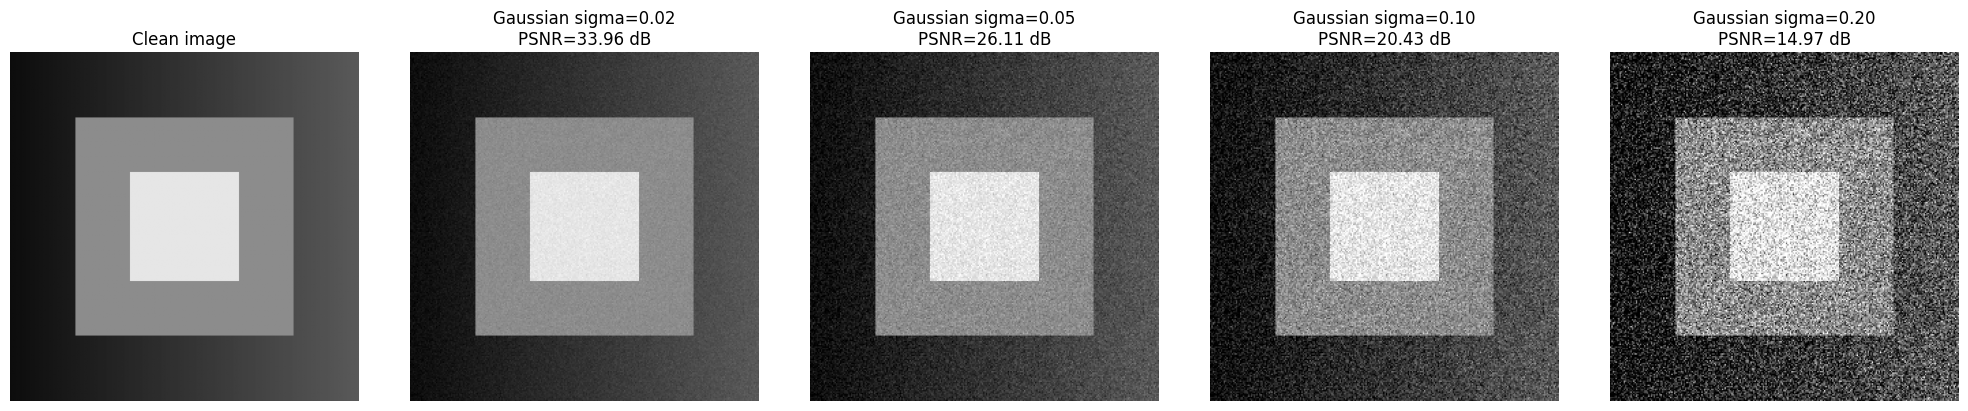

In [7]:
display_images = [
    clean_image,
    *gaussian_noisy_images
]

display_titles = [
    "Clean image",
    *[
        (
            f"Gaussian sigma={sigma:.2f}\n"
            f"PSNR={psnr:.2f} dB"
        )
        for sigma, psnr in zip(
            gaussian_sigmas,
            gaussian_psnr_values
        )
    ]
]

fig, axes = plt.subplots(
    1,
    len(display_images),
    figsize=(20, 4),
    constrained_layout=True
)

for ax, current_image, title in zip(
    axes,
    display_images,
    display_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title(title)
    ax.axis("off")

plt.show()

In [8]:
poisson_rng = np.random.default_rng(
    seed=123
)

peak_levels = [
    100,
    30,
    10,
    5
]

poisson_noisy_images = []
poisson_psnr_values = []

for peak in peak_levels:
    # 将归一化强度转换为期望光子计数
    expected_counts = (
        clean_image * peak
    )

    # 根据泊松分布生成实际光子计数
    photon_counts = poisson_rng.poisson(
        expected_counts
    )

    # 重新归一化到图像强度范围
    noisy_image = (
        photon_counts.astype(np.float32)
        / peak
    )

    noisy_image = np.clip(
        noisy_image,
        0.0,
        1.0
    )

    current_psnr = calculate_psnr(
        clean_image,
        noisy_image
    )

    poisson_noisy_images.append(
        noisy_image
    )

    poisson_psnr_values.append(
        current_psnr
    )

    print(
        f"peak={peak:3d}, "
        f"PSNR={current_psnr:.2f} dB"
    )

peak=100, PSNR=24.53 dB
peak= 30, PSNR=19.55 dB
peak= 10, PSNR=15.05 dB
peak=  5, PSNR=12.44 dB


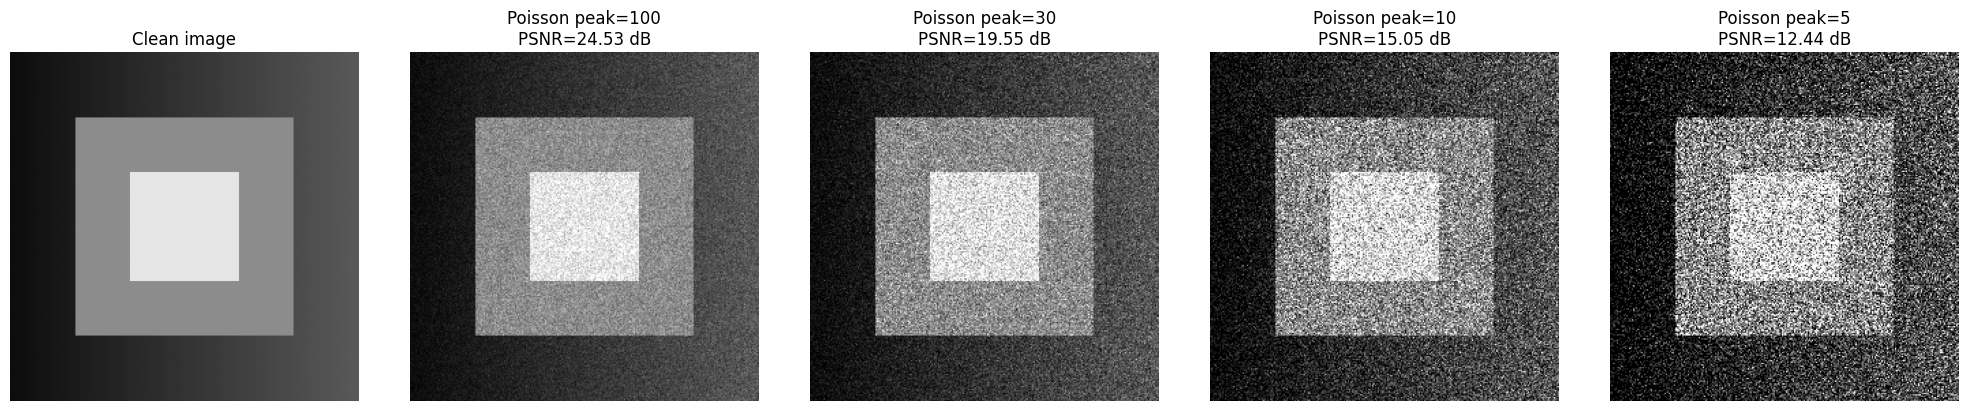

In [9]:
display_images = [
    clean_image,
    *poisson_noisy_images
]

display_titles = [
    "Clean image",
    *[
        (
            f"Poisson peak={peak}\n"
            f"PSNR={psnr:.2f} dB"
        )
        for peak, psnr in zip(
            peak_levels,
            poisson_psnr_values
        )
    ]
]

fig, axes = plt.subplots(
    1,
    len(display_images),
    figsize=(20, 4),
    constrained_layout=True
)

for ax, current_image, title in zip(
    axes,
    display_images,
    display_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title(title)
    ax.axis("off")

plt.show()



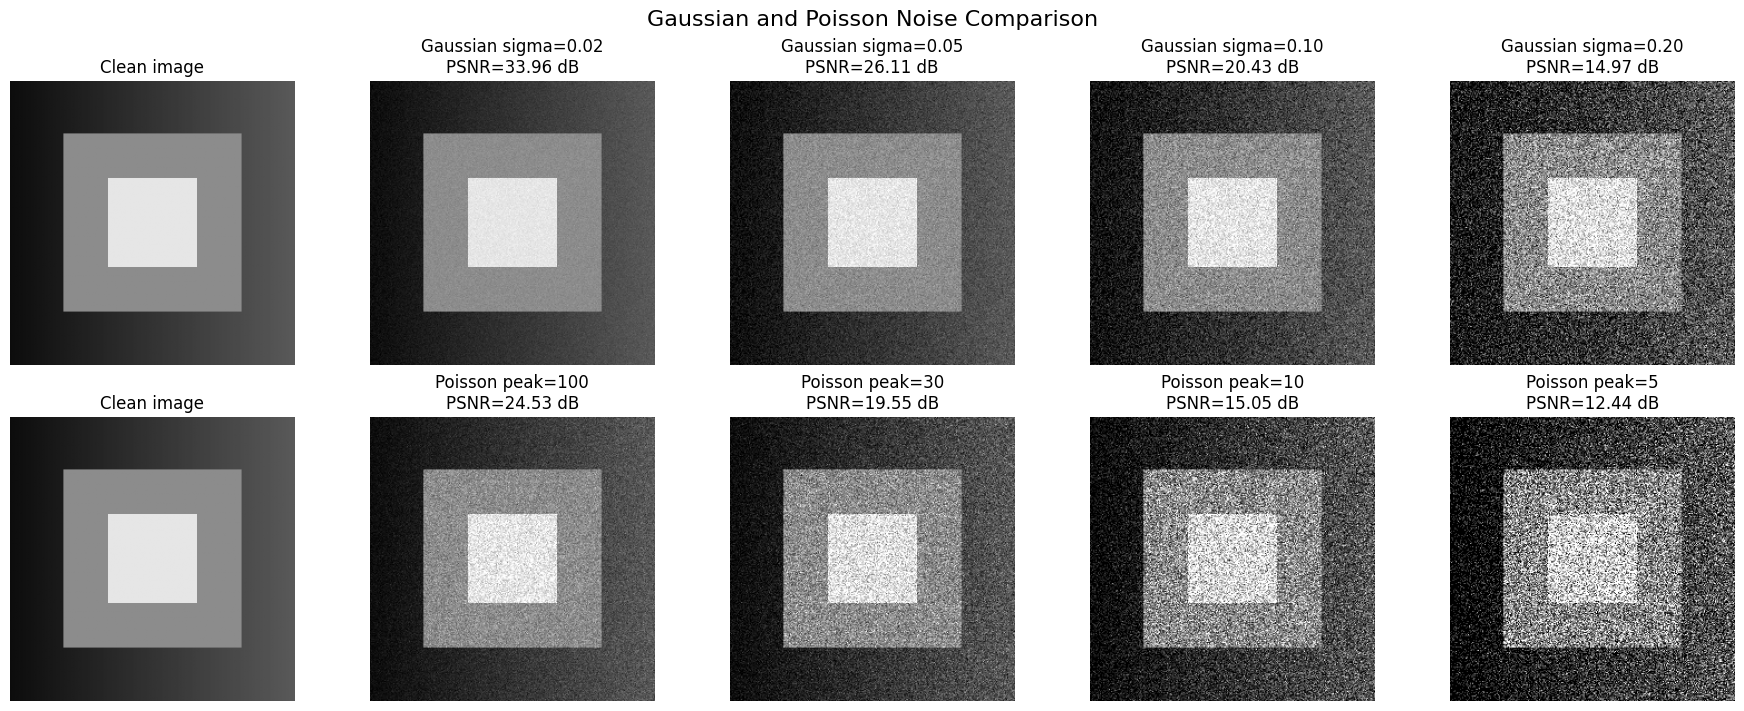

In [10]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 7),
    constrained_layout=True
)

# 第一行：高斯噪声
gaussian_display_images = [
    clean_image,
    *gaussian_noisy_images
]

gaussian_titles = [
    "Clean image",
    *[
        (
            f"Gaussian sigma={sigma:.2f}\n"
            f"PSNR={psnr:.2f} dB"
        )
        for sigma, psnr in zip(
            gaussian_sigmas,
            gaussian_psnr_values
        )
    ]
]

for ax, current_image, title in zip(
    axes[0],
    gaussian_display_images,
    gaussian_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )
    ax.set_title(title)
    ax.axis("off")

# 第二行：泊松噪声
poisson_display_images = [
    clean_image,
    *poisson_noisy_images
]

poisson_titles = [
    "Clean image",
    *[
        (
            f"Poisson peak={peak}\n"
            f"PSNR={psnr:.2f} dB"
        )
        for peak, psnr in zip(
            peak_levels,
            poisson_psnr_values
        )
    ]
]

for ax, current_image, title in zip(
    axes[1],
    poisson_display_images,
    poisson_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(
    "Gaussian and Poisson Noise Comparison",
    fontsize=16
)

plt.show()

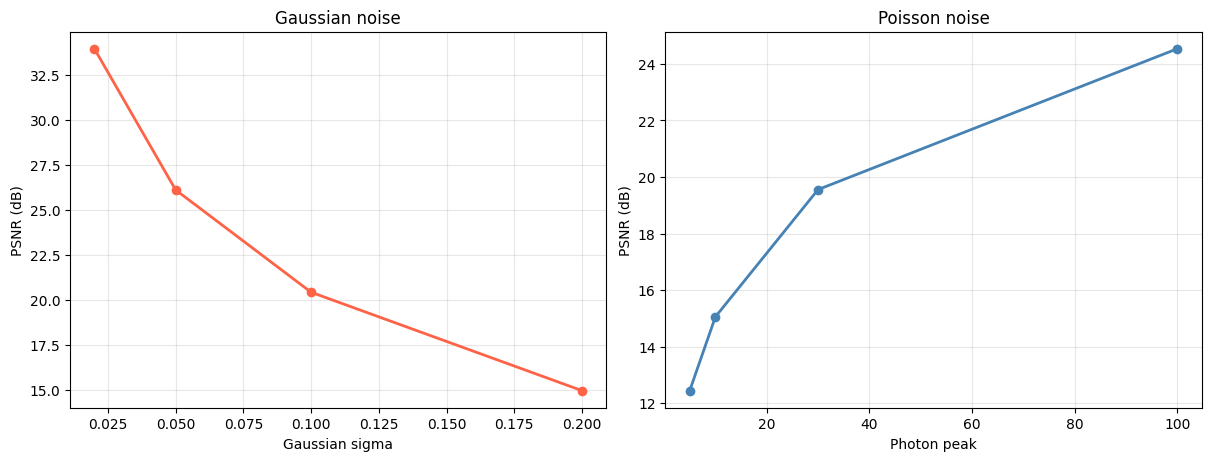

In [11]:
fig_psnr, axes_psnr = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True
)

# 高斯噪声曲线
axes_psnr[0].plot(
    gaussian_sigmas,
    gaussian_psnr_values,
    marker="o",
    linewidth=2,
    color="tomato"
)

axes_psnr[0].set_title(
    "Gaussian noise"
)
axes_psnr[0].set_xlabel(
    "Gaussian sigma"
)
axes_psnr[0].set_ylabel(
    "PSNR (dB)"
)
axes_psnr[0].grid(alpha=0.3)

# 将泊松peak按照从小到大排列
peak_array = np.array(
    peak_levels
)

poisson_psnr_array = np.array(
    poisson_psnr_values
)

peak_order = np.argsort(
    peak_array
)

sorted_peaks = peak_array[
    peak_order
]

sorted_poisson_psnr = poisson_psnr_array[
    peak_order
]

# 泊松噪声曲线
axes_psnr[1].plot(
    sorted_peaks,
    sorted_poisson_psnr,
    marker="o",
    linewidth=2,
    color="steelblue"
)

axes_psnr[1].set_title(
    "Poisson noise"
)
axes_psnr[1].set_xlabel(
    "Photon peak"
)
axes_psnr[1].set_ylabel(
    "PSNR (dB)"
)
axes_psnr[1].grid(alpha=0.3)

plt.show()

In [12]:
output_dir = Path(
    r"C:\Users\ET\projects\dl-learning-journey"
) / "assignments" / "04_noise_psnr" / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

noise_examples_path = (
    output_dir
    / "noise_examples.png"
)

psnr_curves_path = (
    output_dir
    / "psnr_noise_level_curves.png"
)

fig.savefig(
    noise_examples_path,
    dpi=200,
    bbox_inches="tight"
)

fig_psnr.savefig(
    psnr_curves_path,
    dpi=200,
    bbox_inches="tight"
)

print("噪声对比图：")
print(noise_examples_path)
print("是否存在：", noise_examples_path.exists())

print("\nPSNR曲线图：")
print(psnr_curves_path)
print("是否存在：", psnr_curves_path.exists())

噪声对比图：
C:\Users\ET\projects\dl-learning-journey\assignments\04_noise_psnr\outputs\noise_examples.png
是否存在： True

PSNR曲线图：
C:\Users\ET\projects\dl-learning-journey\assignments\04_noise_psnr\outputs\psnr_noise_level_curves.png
是否存在： True
